# Задание 3. Visualizations — снижение размерности MNIST

## Цель

Представить изображения MNIST в виде векторов из 784 признаков и получить двумерное представление шестью методами:

1. PCA
2. SVD
3. Randomized SVD
4. t-SNE
5. UMAP
6. LLE

После этого сравнить методы не только визуально, но и количественно по способности разделять классы цифр.

> В соответствии с заданием метки цифр используются для **оценки качества уже полученных представлений**, а не для обучения методов снижения размерности.


## Критерии сравнения

Используем одинаковую выборку MNIST для всех методов и следующие показатели:

- **Silhouette Score** — чем выше, тем лучше разделение классов;
- **Davies–Bouldin Index** — чем ниже, тем лучше;
- время преобразования — для понимания вычислительной стоимости.

Дополнительно строим scatter plot для каждого метода.

По чек-листу ожидается, что **t-SNE покажет одни из лучших результатов по разделению классов**.


In [1]:
import gzip
import struct
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE, LocallyLinearEmbedding
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.model_selection import train_test_split

try:
    import umap.umap_ as umap
except ImportError as exc:
    raise ImportError(
        "Не найден пакет umap-learn. Выполни в Jupyter: %pip install umap-learn"
    ) from exc

RANDOM_STATE = 42

# Для одинакового и воспроизводимого сравнения всех методов.
# 5000 объектов достаточно для наглядных 2D-визуализаций и
# существенно быстрее полного MNIST.
N_VISUALIZATION_SAMPLES = 5000

PCA_COMPONENTS = 2
SVD_COMPONENTS = 2
RANDOMIZED_SVD_COMPONENTS = 2

TSNE_PERPLEXITY = 30
UMAP_NEIGHBORS = 15
UMAP_COMPONENTS = 2

LLE_NEIGHBORS = 15
LLE_COMPONENTS = 2

print("Python environment готов.")


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python environment готов.


## 1. Поиск файлов MNIST

Используем четыре стандартных файла MNIST в формате IDX, сжатые в gzip.


In [2]:
DATA_CANDIDATES = [
    Path("data/MNIST"),
    Path("../data/MNIST"),
    Path("../../data/MNIST"),
]

MNIST_DIR = next(
    (path for path in DATA_CANDIDATES if (path / "train-images-idx3-ubyte.gz").exists()),
    None,
)

if MNIST_DIR is None:
    raise FileNotFoundError(
        "Не найдена папка data/MNIST. Проверь структуру проекта."
    )

TRAIN_IMAGES = MNIST_DIR / "train-images-idx3-ubyte.gz"
TRAIN_LABELS = MNIST_DIR / "train-labels-idx1-ubyte.gz"
TEST_IMAGES = MNIST_DIR / "t10k-images-idx3-ubyte.gz"
TEST_LABELS = MNIST_DIR / "t10k-labels-idx1-ubyte.gz"

print("MNIST directory:", MNIST_DIR.resolve())


MNIST directory: C:\Users\User\Desktop\ML6_Unsupervised_learning_ID_1254805-1\src\data\MNIST


## 2. Загрузка IDX MNIST

Не используем специальные DL-фреймворки: читаем стандартный бинарный формат MNIST напрямую.


In [3]:
def read_idx_images(path: Path) -> np.ndarray:
    with gzip.open(path, "rb") as f:
        magic, n_images, rows, cols = struct.unpack(">IIII", f.read(16))
        if magic != 2051:
            raise ValueError(f"Неверный magic number для images: {magic}")

        data = np.frombuffer(
            f.read(),
            dtype=np.uint8,
        )

    expected = n_images * rows * cols
    if data.size != expected:
        raise ValueError(
            f"Ожидалось {expected} байт, получено {data.size}"
        )

    return data.reshape(n_images, rows, cols)


def read_idx_labels(path: Path) -> np.ndarray:
    with gzip.open(path, "rb") as f:
        magic, n_labels = struct.unpack(">II", f.read(8))
        if magic != 2049:
            raise ValueError(f"Неверный magic number для labels: {magic}")

        data = np.frombuffer(
            f.read(),
            dtype=np.uint8,
        )

    if data.size != n_labels:
        raise ValueError(
            f"Ожидалось {n_labels} labels, получено {data.size}"
        )

    return data


X_train_images = read_idx_images(TRAIN_IMAGES)
y_train = read_idx_labels(TRAIN_LABELS)

X_test_images = read_idx_images(TEST_IMAGES)
y_test = read_idx_labels(TEST_LABELS)

print("Train images:", X_train_images.shape)
print("Train labels:", y_train.shape)
print("Test images:", X_test_images.shape)
print("Test labels:", y_test.shape)


Train images: (60000, 28, 28)
Train labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


## 3. Представляем каждую цифру как вектор

Каждая MNIST-картинка имеет размер `28 × 28`, поэтому после flatten получается:

`28 × 28 = 784 признака`.

Интенсивности пикселей нормализуем в диапазон `[0, 1]`.


In [4]:
X_train = X_train_images.reshape(X_train_images.shape[0], -1).astype(np.float32) / 255.0
X_test = X_test_images.reshape(X_test_images.shape[0], -1).astype(np.float32) / 255.0

print("Размерность одного изображения:", X_train.shape[1])
assert X_train.shape[1] == 784


Размерность одного изображения: 784


## 4. Формируем одну воспроизводимую выборку для сравнения

Для честного сравнения все шесть методов получат одни и те же объекты.
Выборка делается стратифицированно, чтобы все классы `0..9` были представлены.


In [5]:
sample_indices, _ = train_test_split(
    np.arange(len(X_train)),
    train_size=N_VISUALIZATION_SAMPLES,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

X = X_train[sample_indices]
y = y_train[sample_indices]

print("Размер выборки:", X.shape)
print("Распределение классов:")
display(pd.Series(y).value_counts().sort_index())


Размер выборки: (5000, 784)
Распределение классов:


0    493
1    562
2    496
3    511
4    487
5    452
6    493
7    522
8    488
9    496
Name: count, dtype: int64

# 5. Вспомогательная функция оценки embedding

Методы снижения размерности не получают `y` при построении embedding. После получения 2D-представления используем реальные метки только для расчёта метрик разделения классов.


In [6]:
def evaluate_embedding(name, embedding, elapsed_seconds):
    silhouette = silhouette_score(
        embedding,
        y,
        metric="euclidean",
    )
    davies_bouldin = davies_bouldin_score(
        embedding,
        y,
    )

    return {
        "Method": name,
        "Dimensions": embedding.shape[1],
        "Silhouette": silhouette,
        "Davies-Bouldin": davies_bouldin,
        "Time, sec": elapsed_seconds,
    }


# 6. PCA

PCA ищет направления максимальной дисперсии и проецирует данные на первые две главные компоненты.


In [7]:
start = time.perf_counter()

pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE,
)

X_pca = pca.fit_transform(X)

pca_time = time.perf_counter() - start

pca_result = evaluate_embedding("PCA", X_pca, pca_time)

print(f"Время: {pca_time:.3f} сек")
print(f"Explained variance (2 components): {pca.explained_variance_ratio_.sum():.4f}")


Время: 0.079 сек
Explained variance (2 components): 0.1692


# 7. SVD

Используем truncated SVD и оставляем первые две компоненты.

`TruncatedSVD` позволяет непосредственно работать с матрицами признаков и является практической реализацией усечённого сингулярного разложения.


In [8]:
start = time.perf_counter()

svd = TruncatedSVD(
    n_components=2,
    random_state=RANDOM_STATE,
)

X_svd = svd.fit_transform(X)

svd_time = time.perf_counter() - start

svd_result = evaluate_embedding("SVD", X_svd, svd_time)

print(f"Время: {svd_time:.3f} сек")
print(f"Explained variance ratio sum: {svd.explained_variance_ratio_.sum():.4f}")


Время: 0.133 сек
Explained variance ratio sum: 0.1431


# 8. Randomized SVD

Для Randomized SVD используем случайную алгоритмику `TruncatedSVD`.

Фиксируем `random_state`, чтобы результат был воспроизводимым.


In [9]:
start = time.perf_counter()

randomized_svd = TruncatedSVD(
    n_components=2,
    algorithm="randomized",
    n_iter=7,
    random_state=RANDOM_STATE,
)

X_randomized_svd = randomized_svd.fit_transform(X)

randomized_svd_time = time.perf_counter() - start

randomized_svd_result = evaluate_embedding(
    "Randomized SVD",
    X_randomized_svd,
    randomized_svd_time,
)

print(f"Время: {randomized_svd_time:.3f} сек")
print(
    f"Explained variance ratio sum: "
    f"{randomized_svd.explained_variance_ratio_.sum():.4f}"
)


Время: 0.053 сек
Explained variance ratio sum: 0.1431


# 9. t-SNE

t-SNE строит нелинейное 2D-представление, стараясь сохранить структуру соседств.

Для воспроизводимости фиксируем `random_state`.


In [10]:
start = time.perf_counter()

tsne = TSNE(
    n_components=2,
    perplexity=TSNE_PERPLEXITY,
    init="pca",
    learning_rate="auto",
    max_iter=1000,
    random_state=RANDOM_STATE,
)

X_tsne = tsne.fit_transform(X)

tsne_time = time.perf_counter() - start

tsne_result = evaluate_embedding("t-SNE", X_tsne, tsne_time)

print(f"Время: {tsne_time:.3f} сек")


Время: 19.986 сек


# 10. UMAP

UMAP использует локальную структуру ближайших соседей и строит двумерное нелинейное представление.


In [11]:
start = time.perf_counter()

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=UMAP_NEIGHBORS,
    min_dist=0.1,
    metric="euclidean",
    random_state=RANDOM_STATE,
)

X_umap = umap_model.fit_transform(X)

umap_time = time.perf_counter() - start

umap_result = evaluate_embedding("UMAP", X_umap, umap_time)

print(f"Время: {umap_time:.3f} сек")


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Время: 38.830 сек


# 11. LLE

LLE сохраняет локальные линейные отношения между каждой точкой и её ближайшими соседями.


In [12]:
start = time.perf_counter()

lle = LocallyLinearEmbedding(
    n_neighbors=LLE_NEIGHBORS,
    n_components=2,
    method="standard",
    eigen_solver="auto",
    random_state=RANDOM_STATE,
)

X_lle = lle.fit_transform(X)

lle_time = time.perf_counter() - start

lle_result = evaluate_embedding("LLE", X_lle, lle_time)

print(f"Время: {lle_time:.3f} сек")


Время: 12.418 сек


# 12. Визуализация результатов

На всех графиках цвет соответствует истинному классу цифры. Эти метки **не использовались для получения embedding** — они применяются только для визуальной интерпретации и оценки.


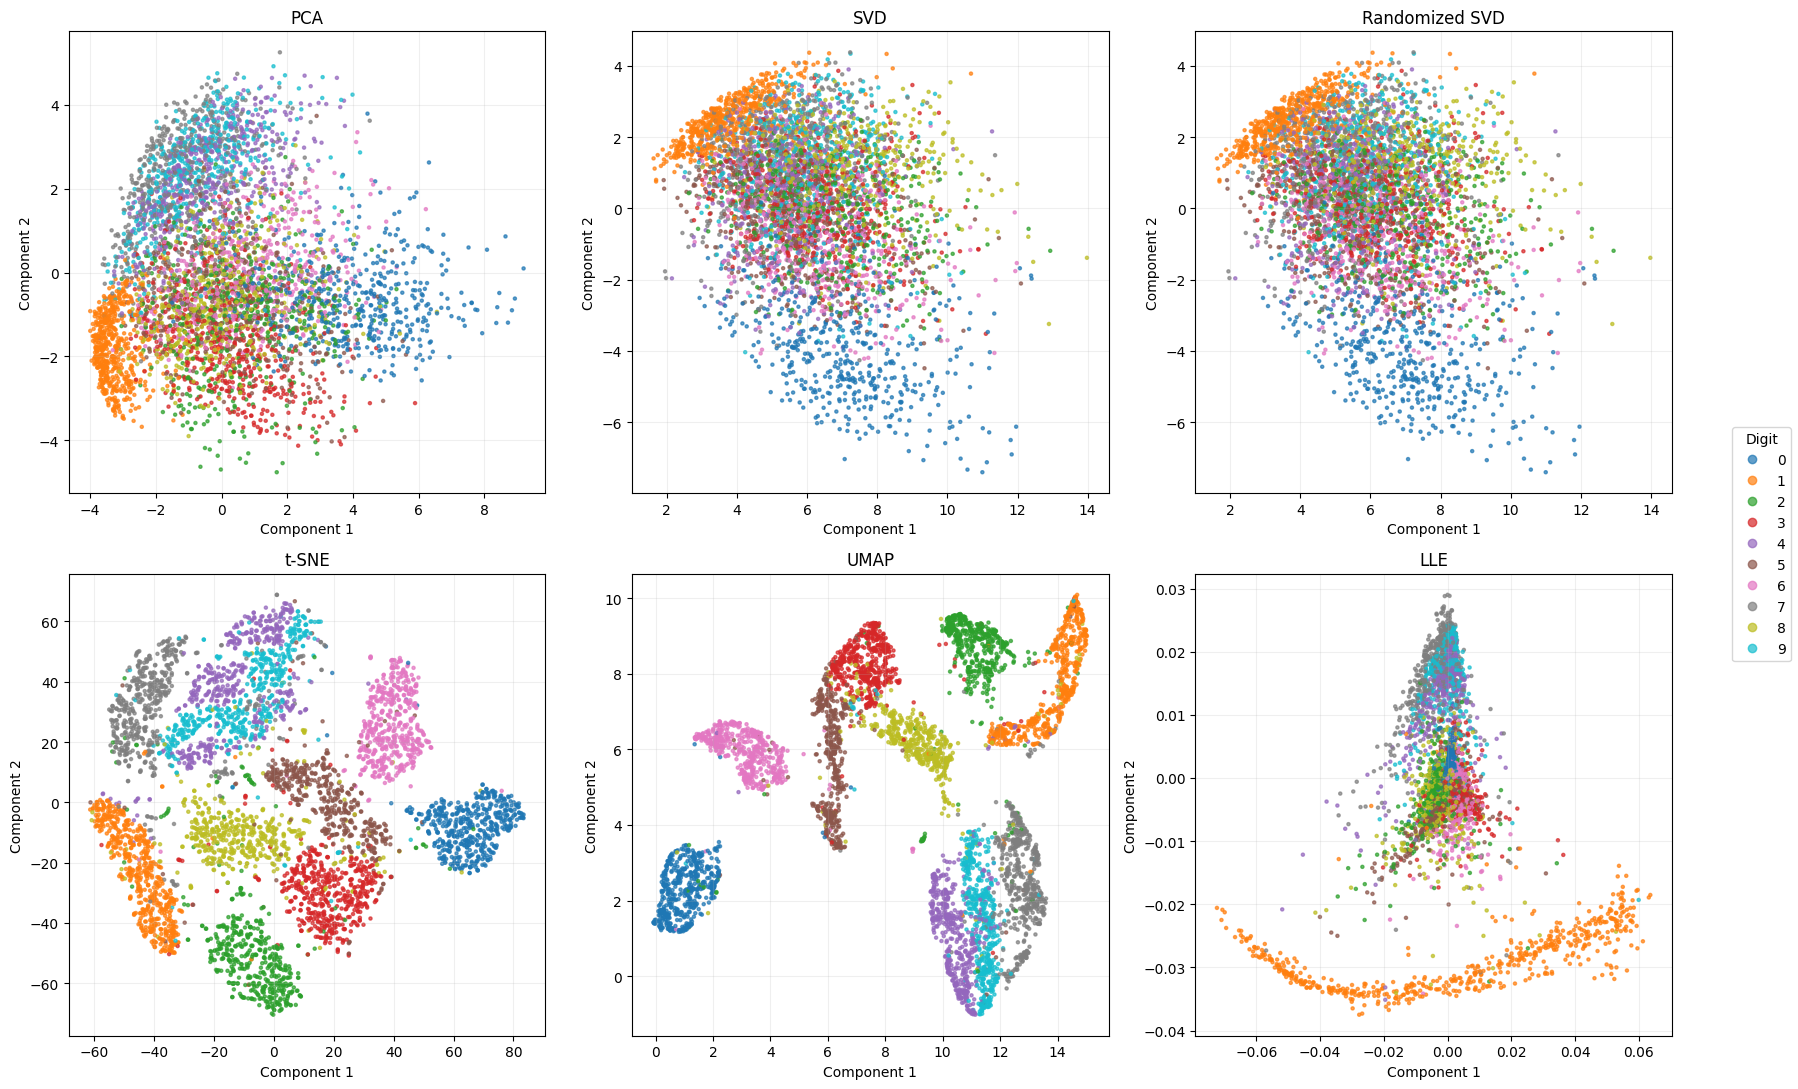

In [13]:
embeddings = {
    "PCA": X_pca,
    "SVD": X_svd,
    "Randomized SVD": X_randomized_svd,
    "t-SNE": X_tsne,
    "UMAP": X_umap,
    "LLE": X_lle,
}

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

for ax, (name, embedding) in zip(axes.ravel(), embeddings.items()):
    scatter = ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=y,
        s=5,
        alpha=0.7,
        cmap="tab10",
    )
    ax.set_title(name)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.grid(alpha=0.2)

handles, labels = scatter.legend_elements(num=10)
fig.legend(
    handles,
    [str(i) for i in range(10)],
    title="Digit",
    loc="center right",
)

plt.tight_layout(rect=(0, 0, 0.94, 1))
plt.show()


# 13. Сравнение метрик

Собираем результаты всех шести методов в одну таблицу.


In [14]:
results = pd.DataFrame([
    pca_result,
    svd_result,
    randomized_svd_result,
    tsne_result,
    umap_result,
    lle_result,
])

results = results.sort_values(
    "Silhouette",
    ascending=False,
).reset_index(drop=True)

display(
    results.round({
        "Silhouette": 4,
        "Davies-Bouldin": 4,
        "Time, sec": 3,
    })
)


,Method,Dimensions,Silhouette,Davies-Bouldin,"Time, sec"
0,UMAP,2,0.3635,1.3733,38.830
1,t-SNE,2,0.3068,2.1774,19.986
2,PCA,2,0.0149,6.3217,0.079
3,Randomized SVD,2,-0.0398,5.5155,0.053
4,SVD,2,-0.0398,5.5156,0.133
5,LLE,2,-0.0555,9.7593,12.418


## 14. Отдельные графики качества

Для интерпретации:

- больше `Silhouette` → лучше;
- меньше `Davies-Bouldin` → лучше.


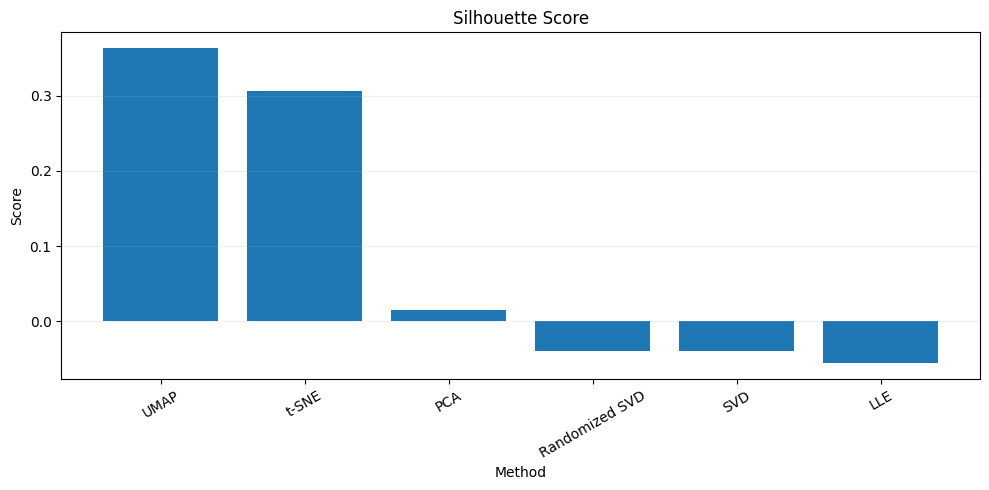

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(results["Method"], results["Silhouette"])
ax.set_title("Silhouette Score")
ax.set_ylabel("Score")
ax.set_xlabel("Method")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


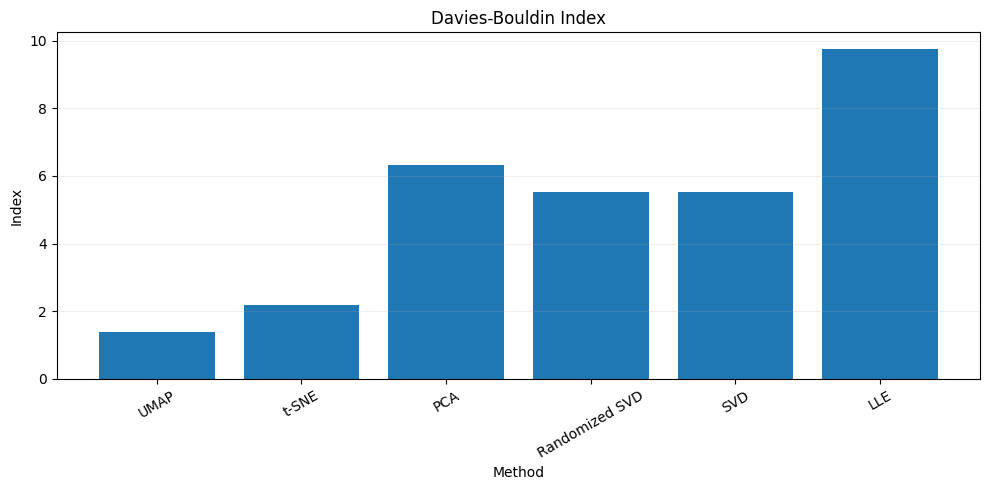

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(results["Method"], results["Davies-Bouldin"])
ax.set_title("Davies-Bouldin Index")
ax.set_ylabel("Index")
ax.set_xlabel("Method")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


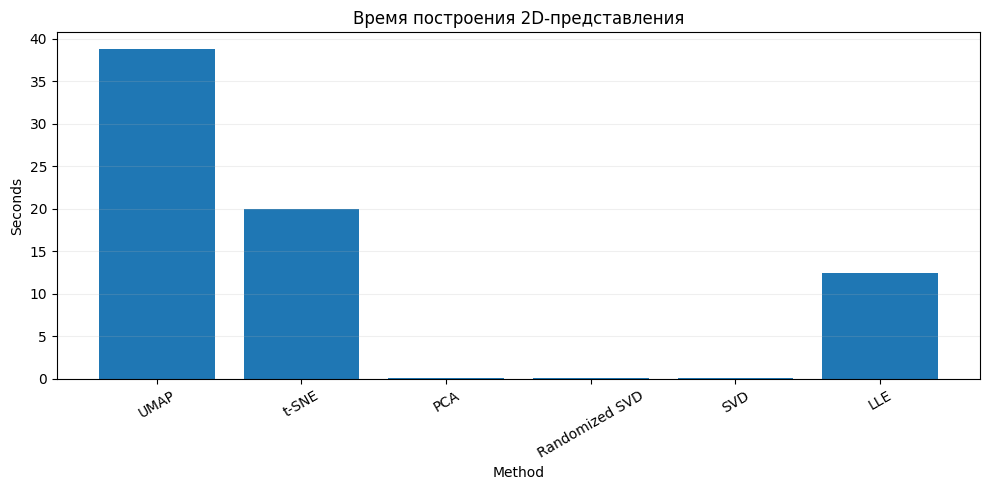

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(results["Method"], results["Time, sec"])
ax.set_title("Время построения 2D-представления")
ax.set_ylabel("Seconds")
ax.set_xlabel("Method")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


# 15. Автоматическое определение лучшего метода

Выводим метод с максимальным Silhouette и минимальным Davies-Bouldin.


In [18]:
best_silhouette = results.loc[
    results["Silhouette"].idxmax()
]

best_db = results.loc[
    results["Davies-Bouldin"].idxmin()
]

print(
    "Лучший по Silhouette:",
    best_silhouette["Method"],
    f"({best_silhouette['Silhouette']:.4f})",
)

print(
    "Лучший по Davies-Bouldin:",
    best_db["Method"],
    f"({best_db['Davies-Bouldin']:.4f})",
)


Лучший по Silhouette: UMAP (0.3635)
Лучший по Davies-Bouldin: UMAP (1.3733)


# 16. Сохранение результатов

Сохраняем embeddings, чтобы не пересчитывать дорогие нелинейные методы при дальнейшей работе.


In [19]:
OUTPUT_DIR = MNIST_DIR.parent / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

np.save(OUTPUT_DIR / "mnist_labels_5000.npy", y)

for name, embedding in embeddings.items():
    safe_name = name.lower().replace("-", "_").replace(" ", "_")
    np.save(
        OUTPUT_DIR / f"mnist_{safe_name}_2d.npy",
        embedding,
    )

results.to_csv(
    OUTPUT_DIR / "mnist_dimensionality_reduction_results.csv",
    index=False,
)

print("Результаты сохранены в:", OUTPUT_DIR.resolve())


Результаты сохранены в: C:\Users\User\Desktop\ML6_Unsupervised_learning_ID_1254805-1\src\data\processed


# 17. Вывод по Task 3

В финальном выводе нужно сравнить методы по трём аспектам:

1. **качество разделения классов** — Silhouette и Davies-Bouldin;
2. **визуальное качество** — насколько хорошо группы цифр отделены на 2D-графике;
3. **вычислительная стоимость** — время получения embedding.

Особенно важно отметить различие между методами:

- PCA/SVD — линейные методы;
- t-SNE/UMAP/LLE — нелинейные методы.

По чек-листу проекта ожидается, что t-SNE продемонстрирует очень хорошее разделение классов. При этом окончательный вывод должен опираться на фактически полученные метрики, а не только на внешний вид графика.


# Контрольный список Task 3

- [x] MNIST загружен
- [x] изображения представлены в виде векторов
- [x] 28 × 28 → 784 признака
- [x] PCA → 2D
- [x] SVD → 2D
- [x] Randomized SVD → 2D
- [x] t-SNE → 2D
- [x] UMAP → 2D
- [x] LLE → 2D
- [x] визуализации построены
- [x] Silhouette Score рассчитан
- [x] Davies-Bouldin Index рассчитан
- [x] время рассчитано
- [x] результаты собраны в одну таблицу
- [x] embeddings сохранены
